In [26]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
from collections import defaultdict
from sklearn import metrics
from sklearn.base import BaseEstimator

cwd = Path.cwd().resolve()
for p in cwd.parents:
    if (p / '.git').exists():
        %cd {str(p)}
        break

In [2]:
df = pd.read_csv('data/processed/order_delivery_dataset.csv')
df.head()

,order_id,order_approved_at,order_delivered_carrier_date,customer_lat,customer_lng,customer_state,seller_lat,seller_lng,seller_state,distance_km,item_count,volume_m3,weight_kg,total_price,total_freight_value,handling_days,transit_days,total_delivery_days
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 09:45:35,2017-09-19 18:34:16,-21.762775,-41.309633,RJ,-22.496953,-44.127492,RJ,301.504681,1,0.003528,0.65,58.90,13.29,6.367141,1.214954,7.582095
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 11:05:13,2017-05-04 14:35:00,-20.220527,-50.903424,SP,-23.565096,-46.518565,SP,585.563937,1,0.060000,30.00,239.90,19.93,8.145683,8.062083,16.207766
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:48:30,2018-01-16 12:36:48,-19.870305,-44.593326,MG,-22.262584,-46.171124,MG,312.343511,1,0.014157,3.05,199.00,17.87,1.908542,6.029491,7.938032
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:10:18,2018-08-10 13:28:00,-23.089925,-46.611654,SP,-20.553624,-47.387359,SP,293.168420,1,0.002400,0.20,12.99,12.79,2.137292,4.003229,6.140521
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 14:10:13,2017-02-16 09:46:09,-23.243402,-46.827614,SP,-22.929384,-53.135873,PR,646.163463,1,0.042000,3.75,199.90,18.14,11.816620,13.289144,25.105764


In [3]:
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])

# Data Split

In [4]:
df['order_approved_at'].groupby(df.order_approved_at.dt.to_period('M')).count()

order_approved_at
2017-01     711
2017-02    1626
2017-03    2548
2017-04    2236
2017-05    3502
2017-06    3115
2017-07    3763
2017-08    4137
2017-09    4113
2017-10    4378
2017-11    7055
2017-12    5610
2018-01    6889
2018-02    6450
2018-03    6994
2018-04    6143
2018-05    6761
2018-06    5895
2018-07    5397
2018-08    6276
Freq: M, Name: order_approved_at, dtype: int64

2017 will be used for training
2018 will be used for testing

In [5]:
df_train = df[df['order_approved_at'].between('2017-01-01', '2017-12-31')].copy()
df_test = df[df['order_approved_at'].between('2018-01-01', '2018-12-31')].copy()

# Feature Engineering and Selection

<Axes: xlabel='order_approved_at', ylabel='handling_days'>

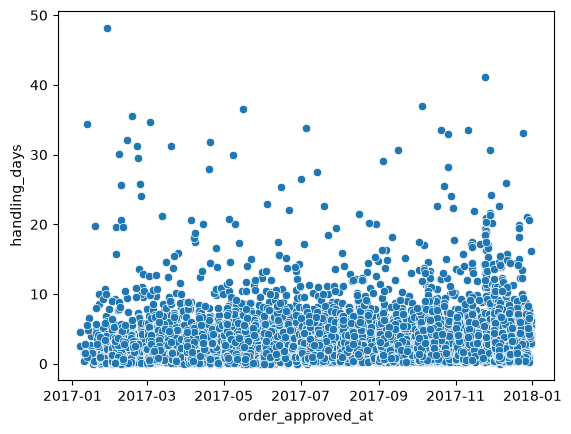

In [7]:
scatter_data = df_train.groupby(df_train['order_approved_at'].dt.to_period('M'), group_keys = False).apply(lambda x : x.sample(frac = 0.2))
sns.scatterplot(data = scatter_data, x = 'order_approved_at', y = 'handling_days')

doesnt seems to be exhibiting trend

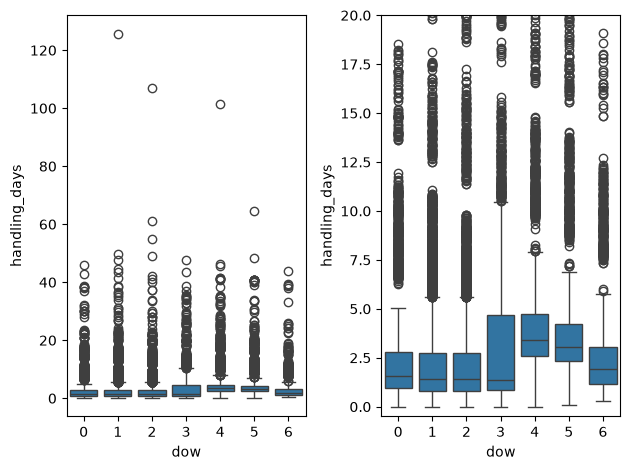

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2)
df_train['dow'] = df_train['order_approved_at'].dt.day_of_week

sns.boxplot(df_train, x = 'dow', y = 'handling_days', ax = ax1)
sns.boxplot(df_train, x = 'dow', y = 'handling_days', ax = ax2)
ax2.set_ylim(-0.5, 20)
plt.tight_layout()

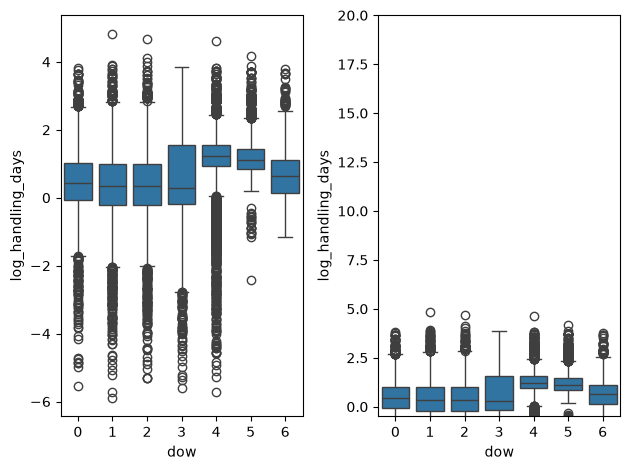

In [9]:
df_train['log_handling_days'] = np.log(df_train['handling_days'])

fig, (ax1, ax2) = plt.subplots(1, 2)
sns.boxplot(df_train, x = 'dow', y = 'log_handling_days', ax = ax1)
sns.boxplot(df_train, x = 'dow', y = 'log_handling_days', ax = ax2)
ax2.set_ylim(-0.5, 20)
plt.tight_layout()

0.14344592259667938


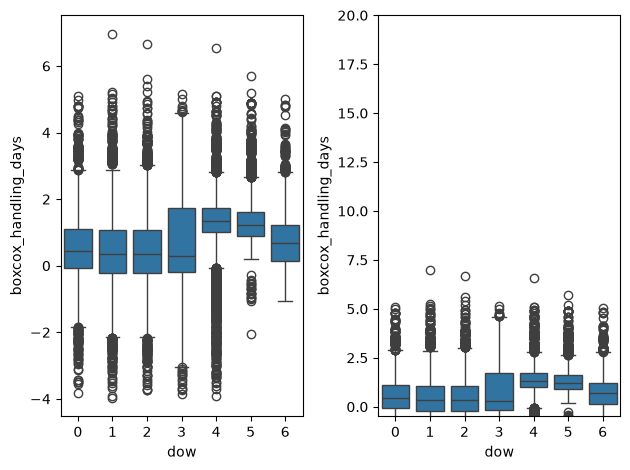

In [10]:
import scipy.stats as ss
df_train['boxcox_handling_days'], optimal_lambda = ss.boxcox(df_train['handling_days'])
print(optimal_lambda)

fig, (ax1, ax2) = plt.subplots(1, 2)
sns.boxplot(df_train, x = 'dow', y = 'boxcox_handling_days', ax = ax1)
sns.boxplot(df_train, x = 'dow', y = 'boxcox_handling_days', ax = ax2)
ax2.set_ylim(-0.5, 20)
plt.tight_layout()

In [11]:
ss.t.shapes

'df'

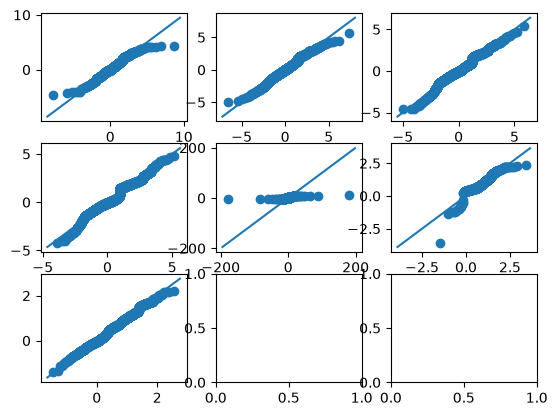

In [12]:
fig, axes = plt.subplots(3, 3)
axes = axes.ravel()

for i in range(7):
    ax = axes[i]
    days = df_train.loc[df_train.dow == i, 'handling_days']
    days, _ = ss.boxcox(days)
    params = ss.t.fit(days)
    q_emp = np.sort(days)
    p = (np.arange(1, len(days) + 1) - 0.5) / len(days)
    q_theo = ss.t.ppf(p, *params)
    ax.scatter(q_theo, q_emp)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims)
    

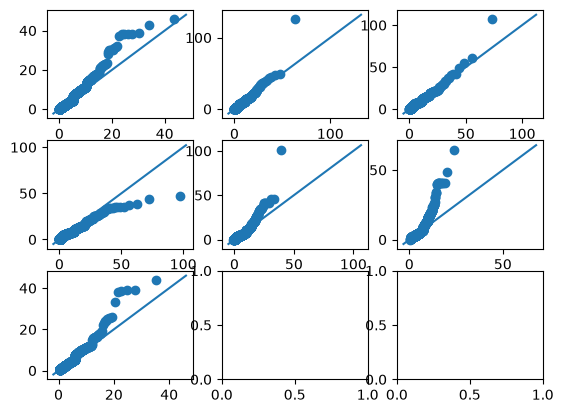

In [13]:
fig, axes = plt.subplots(3, 3)
axes = axes.ravel()

for i in range(7):
    ax = axes[i]
    days = df_train.loc[df_train.dow == i, 'handling_days']
    params = ss.lognorm.fit(days)
    q_emp = np.sort(days)
    p = (np.arange(1, len(days) + 1) - 0.5) / len(days)
    q_theo = ss.lognorm.ppf(p, *params)
    ax.scatter(q_theo, q_emp)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims)
    

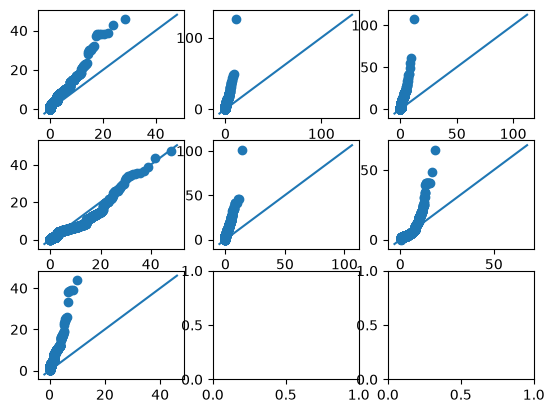

In [14]:
fig, axes = plt.subplots(3, 3)
axes = axes.ravel()

for i in range(7):
    ax = axes[i]
    days = df_train.loc[df_train.dow == i, 'handling_days']
    params = ss.gamma.fit(days)
    q_emp = np.sort(days)
    p = (np.arange(1, len(days) + 1) - 0.5) / len(days)
    q_theo = ss.gamma.ppf(p, *params)
    ax.scatter(q_theo, q_emp)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims)
    

In [15]:
ss.expon.shapes

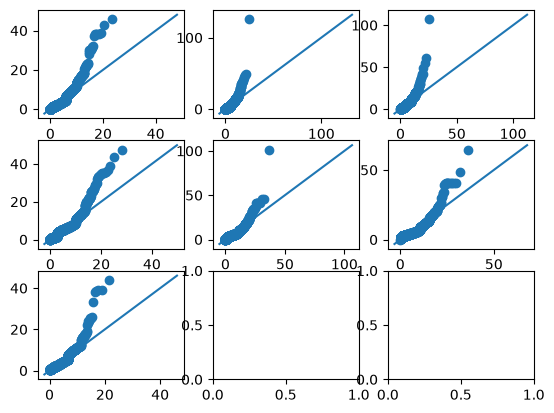

In [16]:
fig, axes = plt.subplots(3, 3)
axes = axes.ravel()

for i in range(7):
    ax = axes[i]
    days = df_train.loc[df_train.dow == i, 'handling_days']
    params = ss.expon.fit(days)
    q_emp = np.sort(days)
    p = (np.arange(1, len(days) + 1) - 0.5) / len(days)
    q_theo = ss.expon.ppf(p, *params)
    ax.scatter(q_theo, q_emp)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims)
    

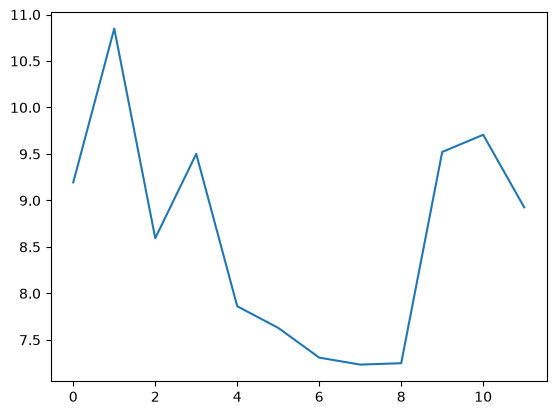

In [17]:
q_emp = []
months = np.unique(df_train.order_approved_at.dt.to_period('M'))
for month in months:
    days = df_train.loc[df_train.order_approved_at.dt.to_period('M') == month, 'handling_days']
    h = 1 + (len(days) - 1) * 0.95
    g = h - int(h)
    days = np.sort(days)
    q_emp.append(days[int(h)] + (days[int(h) + 1] - days[int(h)]) * g)

plt.plot(np.arange(len(months)), q_emp)
    

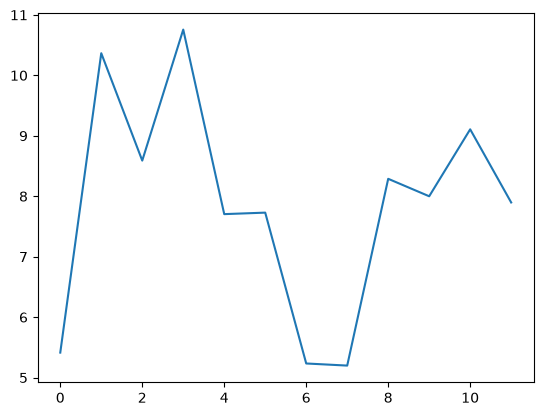

In [18]:
q_emp = []
months = np.unique(df_train.order_approved_at.dt.to_period('M'))
for month in months:
    days = df_train.loc[(df_train.order_approved_at.dt.to_period('M') == month) & (df_train.dow == 6), 'handling_days']
    h = 1 + (len(days) - 1) * 0.95
    g = h - int(h)
    days = np.sort(days)
    q_emp.append(days[int(h)] + (days[int(h) + 1] - days[int(h)]) * g)

plt.plot(np.arange(len(months)), q_emp)
    

handling days appear to have a clear seasonality, in particular, order approved during friday, saturday, and sunday take longer time to be handled

In [19]:
candidate_features = ['dow', 'seller_state', 'seller_lat', 'seller_lng', 'item_count', 'volume_m3', 'weight_kg']

Features such as seller location and distance are not selected because they are deemed irrelevant

In [20]:
df_train.seller_state.value_counts() / len(df_train)

seller_state
SP    0.695107
MG    0.094658
PR    0.071795
SC    0.043503
RJ    0.041256
RS    0.021997
DF    0.009056
BA    0.008284
GO    0.004587
ES    0.004493
MT    0.001474
CE    0.000889
PE    0.000866
MS    0.000655
RN    0.000632
PB    0.000328
RO    0.000234
SE    0.000117
AM    0.000070
Name: count, dtype: float64

In [21]:
df_train.groupby('seller_state')['handling_days'].mean()[df_train.seller_state.value_counts().index]

seller_state
SP    3.045241
MG    2.998630
PR    3.406081
SC    2.695722
RJ    2.725314
RS    3.321468
DF    2.720589
BA    3.093614
GO    2.328483
ES    2.018081
MT    2.129438
CE    2.977924
PE    1.857459
MS    2.704867
RN    5.254270
PB    2.489415
RO    2.224104
SE    0.961546
AM    3.427901
Name: handling_days, dtype: float64

In [22]:
df[['order_delivered_carrier_date', 'order_approved_at']].apply(lambda x : x.dt.dayofweek, axis = 0)

,order_delivered_carrier_date,order_approved_at
0,1,2
1,3,2
2,1,6
3,4,2
4,3,5
...,...,...
93594,2,2
93595,1,1
93596,3,1
93597,1,1


In [23]:
class ZScore:
    def __init__(self, alpha = 0.05):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.array(X)
        y = pd.Series(y)
        
        self.mean = y.groupby(list(X.T)).mean()
        self.std = y.groupby(list(X.T)).std()
        
    def predict(self, X, y):
        X = np.array(X)
        y = np.array(y)
        if X.shape[1] > 1:
            center = self.mean[list(map(tuple, X))]
        else: 
            center = self.mean[X[:, 0]]
        upper_bound = center + ss.norm.ppf(1 - self.alpha) * self.std

        return {
            'is_outlier' : (upper_bound < y).astype(int),
            'center' : center
        }
        
        
zscore = ZScore(alpha = 0.01)
zscore.fit(df_train[['dow']], df_train['handling_days'])
zscore.mean
zscore.predict(df_train[['dow']], df_train['handling_days'])['is_outlier'].mean()

np.float64(0.027636721035265484)

In [40]:

class TScore(BaseEstimator):
    def __init__(self, alpha):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X)
        y = pd.Series(y)

        keys = []
        upper_bounds = []
        centers = []
        for key, ser in y.groupby(list(X.T)):
            keys.append(key)
            t_params = ss.t.fit(ser)
            upper_bounds.append(ss.t.ppf(1 - self.alpha, *t_params))
            centers.append(np.mean(ser))
        print(upper_bounds, centers)
        self.preds = pd.DataFrame(
            {'upper_bound' : upper_bounds, 'center' : centers},
            index = keys
        )
        
    def predict(self, X):
        X = np.array(X)
        
        preds = self.preds.loc[list(map(tuple, X))]

        return {
            'upper_bound' : np.array(preds.upper_bound),
            'center' : np.array(preds.center)
        }
            
        
tscore = TScore(alpha = 0.05)
tscore.fit(df_train[['dow']], df_train['handling_days'])
tscore.predict(df_train[['dow']])

[np.float64(4.6959722634771), np.float64(4.913082262898907), np.float64(5.610785750591181), np.float64(6.744362202163698), np.float64(7.848472334378364), np.float64(6.120140322421246), np.float64(4.726868612160391)] [np.float64(2.521010534561033), np.float64(2.5225652902793407), np.float64(2.697510512681365), np.float64(3.0052776550779416), np.float64(3.8965890165757977), np.float64(3.954008604626346), np.float64(2.647741981075934)]


{'upper_bound': array([5.61078575, 5.61078575, 6.12014032, ..., 6.12014032, 4.91308226,
        4.91308226], shape=(42733,)),
 'center': array([2.69751051, 2.69751051, 3.9540086 , ..., 3.9540086 , 2.52256529,
        2.52256529], shape=(42733,))}

In [24]:
def evaluate(model, X_list, y_list, period_train, period_test):
    """
    period_train : in months
    period_test : in months
    """
    for i, (X, y) in enumerate(zip(X_list, y_list)):
        X_list[i] = np.array(X)
        y_list[i] = np.array(y)

    N = len(X_list) - period_train - period_test + 1
    results = defaultdict(list)
    for i in range(N):
        X_train = np.concatenate(X_list[i : i + period_train], axis = 0)
        y_train = np.concatenate(y_list[i : i + period_train], axis = 0)
        X_test = np.concatenate(X_list[i + period_train : i + period_train + period_test], axis = 0)
        y_test = np.concatenate(y_list[i + period_train : i + period_train + period_test], axis = 0)

        model.fit(X_train, y_train)
        preds = model.predict(X_test, y_test)

        results['outlier_frac'].append(preds['is_outlier'].mean().item())
        results['rmse_center'].append(metrics.root_mean_squared_error(y_test, preds['center']))
        results['N'].append(len(y_test))
        
    for k in results.keys():
        results[k] = np.array(results[k])
    return results
        

results = evaluate(
    model = zscore, 
    X_list = [g[1] for g in df_train[['dow']].groupby(by = df_train.order_approved_at.dt.to_period('M'), sort = True)], 
    y_list = [g[1] for g in df_train['handling_days'].groupby(by = df_train.order_approved_at.dt.to_period('M'), sort = True)],
    period_train = 3, 
    period_test = 1,
)

def aggregate_metrics(result):
    return  {
        'outlier_frac' : np.average(result['outlier_frac'], weights = result['N']).item(),
        'rmse_outlier_frac' : np.sqrt(((result['outlier_frac'] - 0.05)**2).mean()).item(),
        'weighted_rmse_outlier_frac' : np.sqrt(np.average((result['outlier_frac'] - 0.05)**2, weights = result['N'])).item(),
        'rmse_center' : np.sqrt(np.average(results['rmse_center'] ** 2, weights = result['N'])).item()
    }
    
results['outlier_frac'].mean()
aggregate_metrics(results)

{'outlier_frac': 0.03358169520186007,
 'rmse_outlier_frac': 0.02088716232958555,
 'weighted_rmse_outlier_frac': 0.019850000738200483,
 'rmse_center': 3.5196441400130642}